In [650]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression

In [651]:
df = pd.read_csv("player_style_stats.csv")
df.columns = [
    "Randomness",
    "Aggression sensitivity",
    "Rounds played",
    "Amount won relative to big blind",
    "Win per round",
]
df

,Randomness,Aggression sensitivity,Rounds played,Amount won relative to big blind,Win per round
0,0.938120,0.860230,3,-1.00,-0.333333
1,0.393985,0.364122,3,-1.50,-0.500000
2,0.954751,0.097801,3,-18.50,-6.166667
3,0.959220,0.993265,1,1.50,1.500000
4,0.813752,0.910490,4,-1.00,-0.250000
...,...,...,...,...,...
6564,0.700234,1.459098,3,-29.25,-9.750000
6565,0.580280,0.420851,1,-9.25,-9.250000
6566,0.493251,1.556720,0,0.00,0.000000
6567,0.989615,0.410214,1,0.00,0.000000


In [652]:
# Remove outliers (win per round more than X standard deviations from the mean)
df = df[np.abs(df['Win per round'] - df['Win per round'].mean()) <= (3 * df['Win per round'].std())]
df

,Randomness,Aggression sensitivity,Rounds played,Amount won relative to big blind,Win per round
0,0.938120,0.860230,3,-1.00,-0.333333
1,0.393985,0.364122,3,-1.50,-0.500000
2,0.954751,0.097801,3,-18.50,-6.166667
3,0.959220,0.993265,1,1.50,1.500000
4,0.813752,0.910490,4,-1.00,-0.250000
...,...,...,...,...,...
6564,0.700234,1.459098,3,-29.25,-9.750000
6565,0.580280,0.420851,1,-9.25,-9.250000
6566,0.493251,1.556720,0,0.00,0.000000
6567,0.989615,0.410214,1,0.00,0.000000


In [653]:
# Remove data outside bounds (agg sensitivity < 0 or > 2)
df = df[df["Aggression sensitivity"] >= 0]
df = df[df["Aggression sensitivity"] <= 2]
df

,Randomness,Aggression sensitivity,Rounds played,Amount won relative to big blind,Win per round
0,0.938120,0.860230,3,-1.00,-0.333333
1,0.393985,0.364122,3,-1.50,-0.500000
2,0.954751,0.097801,3,-18.50,-6.166667
3,0.959220,0.993265,1,1.50,1.500000
4,0.813752,0.910490,4,-1.00,-0.250000
...,...,...,...,...,...
6564,0.700234,1.459098,3,-29.25,-9.750000
6565,0.580280,0.420851,1,-9.25,-9.250000
6566,0.493251,1.556720,0,0.00,0.000000
6567,0.989615,0.410214,1,0.00,0.000000


In [654]:
df.dtypes

Randomness                          float64
Aggression sensitivity              float64
Rounds played                         int64
Amount won relative to big blind    float64
Win per round                       float64
dtype: object

In [655]:
X = df[["Randomness", "Aggression sensitivity", "Rounds played"]]
y = df["Win per round"]

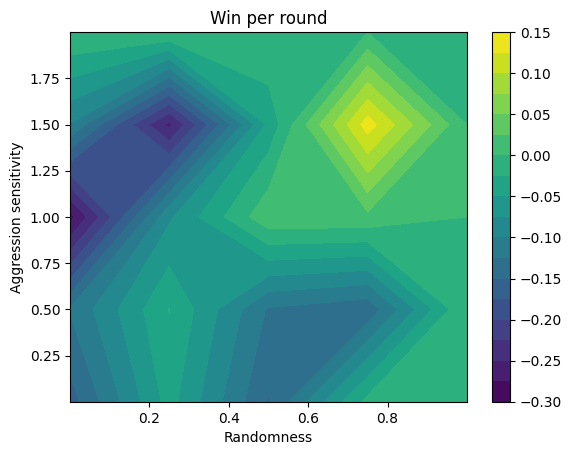

In [656]:
# Plot heatmap of randomness and aggression sensitivity vs win per round
# Create grid with buckets of randomness and aggression sensitivity values:
buckets = 5
r_min = df["Randomness"].min()
r_max = df["Randomness"].max()
a_min = df["Aggression sensitivity"].min()
a_max = df["Aggression sensitivity"].max()
randomness = np.linspace(r_min, r_max, buckets)
aggression_sensitivity = np.linspace(a_min, a_max, buckets)
R, A = np.meshgrid(randomness, aggression_sensitivity)

# For each bucket, get the empirical mean
Z = np.zeros_like(R)
for ri, from_r in enumerate(randomness[:-1]):
    to_r = randomness[ri + 1] if ri + 1 < len(randomness) else r_max
    r_mask = (df["Randomness"] >= from_r) & (df["Randomness"] < to_r)
    for ai, from_a in enumerate(aggression_sensitivity[:-1]):
        to_a = aggression_sensitivity[ai + 1] if ai + 1 < len(aggression_sensitivity) else a_max
        a_mask = (df["Aggression sensitivity"] >= from_a) & (df["Aggression sensitivity"] < to_a)
        mask = r_mask & a_mask
        Z[ai, ri] = df[mask]["Win per round"].mean()

plt.figure()
plt.contourf(R, A, Z, levels=20)
plt.colorbar()
plt.xlabel("Randomness")
plt.ylabel("Aggression sensitivity")
plt.title("Win per round")
plt.show()

Coef: [0.20140126]
P-value: 0.0011833156696905434
2nd degree coefs: [0.19920279 0.00221196]
P-value: 0.0011833251298435377


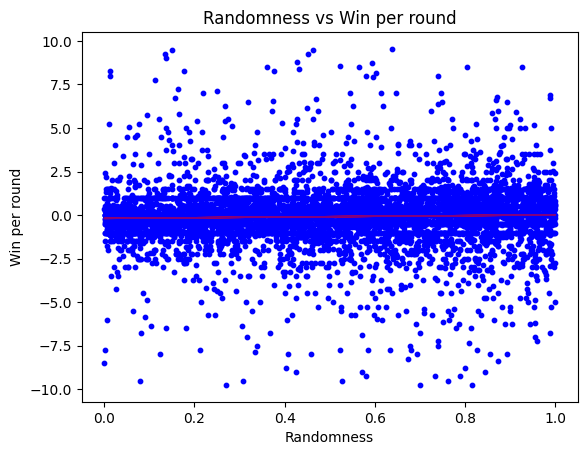

In [657]:
# Plot randomness vs win per round
plt.scatter(df["Randomness"], df["Win per round"], c="blue", s=10)

# Plot trendline
model = LinearRegression().fit(X[["Randomness"]], y)
plt.plot(df["Randomness"], model.predict(X[["Randomness"]]), color="red", linewidth=1)
print("Coef:", model.coef_)
print("P-value:", model.score(X[["Randomness"]], y))

# Plot second degree trend line
X_2nd_deg_rand = X[["Randomness"]].copy()
X_2nd_deg_rand["Randomness^2"] = X_2nd_deg_rand.loc[:, "Randomness"]**2
model = LinearRegression().fit(X_2nd_deg_rand, y)
plt.plot(df["Randomness"], model.predict(X_2nd_deg_rand), color="purple", linewidth=1)
print("2nd degree coefs:", model.coef_)
print("P-value:", model.score(X_2nd_deg_rand, y))

plt.xlabel("Randomness")
plt.ylabel("Win per round")
plt.title("Randomness vs Win per round")
plt.show()

Coef: [0.01282091]
P-value: 1.8651563071903077e-05


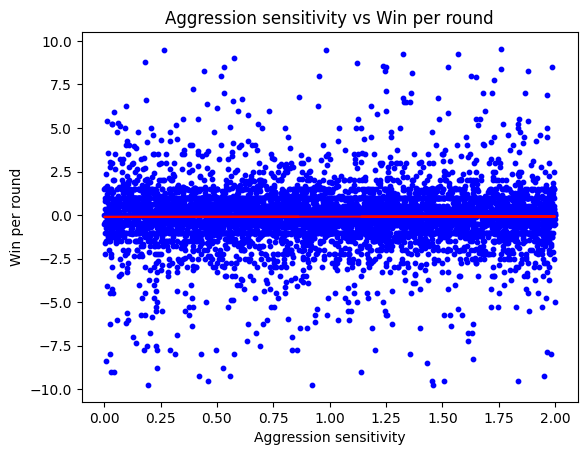

In [658]:
# Plot aggression sensitivity vs win per round
plt.scatter(df["Aggression sensitivity"], df["Win per round"], c="blue", s=10)
model = LinearRegression().fit(X[["Aggression sensitivity"]], y)
print("Coef:", model.coef_)
print("P-value:", model.score(X[["Aggression sensitivity"]], y))
plt.plot(df["Aggression sensitivity"], model.predict(X[["Aggression sensitivity"]]), color="red")
plt.xlabel("Aggression sensitivity")
plt.ylabel("Win per round")
plt.title("Aggression sensitivity vs Win per round")
plt.show()

Coef: [0.03231646]
P-value: 0.006427245208818322


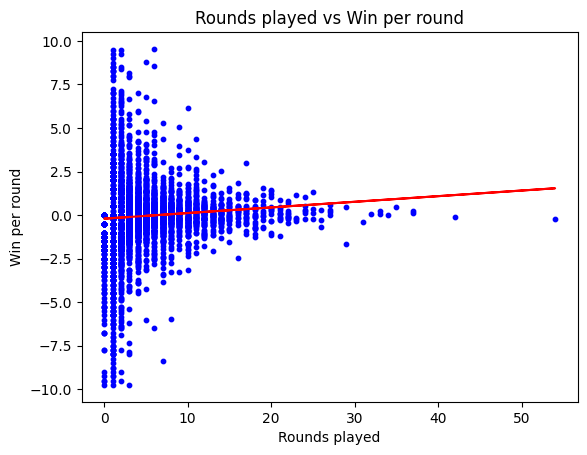

In [659]:
# Plot rounds played vs win per round
plt.scatter(df["Rounds played"], df["Win per round"], c="blue", s=10)
model = LinearRegression().fit(df[["Rounds played"]], y)
print("Coef:", model.coef_)
print("P-value:", model.score(df[["Rounds played"]], y))
plt.plot(df["Rounds played"], model.predict(df[["Rounds played"]]), color="red")
plt.xlabel("Rounds played")
plt.ylabel("Win per round")
plt.title("Rounds played vs Win per round")
plt.show()

In [660]:
# Add combinations of features to capture non-linear relationships
def preprocess(X_df):
    X_df["Randomness squared"] = X_df.loc[:, "Randomness"] ** 2
    X_df["Aggression sensitivity squared"] = X_df.loc[:, "Aggression sensitivity"] ** 2
    X_df["Randomness * Aggression sensitivity"] = X_df.loc[:, "Randomness"] * X_df.loc[:, "Aggression sensitivity"]

preprocess(X)

/var/folders/4_/zn5f20ls53v5r1bw3w8dbh0h0000gn/T/ipykernel_6690/1713679624.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_df["Randomness squared"] = X_df.loc[:, "Randomness"] ** 2


In [661]:
model = LinearRegression()
model.fit(X, y)
coef_df = pd.DataFrame(model.coef_, index=X.columns, columns=["Coefficient"])

In [662]:
# Calculate p-value for each coefficient
f_values, p_values = f_regression(X, y)
coef_df["P-value"] = p_values
coef_df

,Coefficient,P-value
Randomness,0.041691,5.826606e-03
Aggression sensitivity,-0.080523,7.292818e-01
Rounds played,0.031628,1.236922e-10
Randomness squared,0.006828,7.558126e-03
Aggression sensitivity squared,0.014800,7.533504e-01
Randomness * Aggression sensitivity,0.127340,1.444065e-02


Optimal parameters:
 Randomness                1.0
Aggression sensitivity    3.0
Name: 9999, dtype: float64


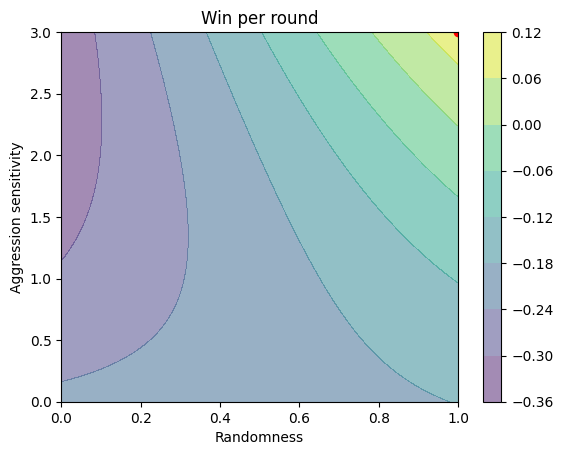

In [663]:
# Contour plot to find the best player style
randomness = np.linspace(0, 1, 100)
aggression = np.linspace(0, 3, 100)
X1, X2 = np.meshgrid(randomness, aggression)
plt_X = np.c_[X1.ravel(), X2.ravel()]
plt_X_df = pd.DataFrame(plt_X, columns=["Randomness", "Aggression sensitivity"])
preprocess(plt_X_df)
plt_X_df["Rounds played"] = 0 # Ignore rounds played here
plt_X_df = plt_X_df[X.columns]
plt_y = model.predict(plt_X_df)
plt_y = plt_y.reshape(X1.shape)

# Calculate optimal player style
optimal_player_style = plt_X_df.loc[np.argmax(plt_y)]
print("Optimal parameters:\n", optimal_player_style[["Randomness", "Aggression sensitivity"]])

plt.contourf(X1, X2, plt_y, alpha=0.5)
plt.colorbar()
plt.xlabel("Randomness")
plt.ylabel("Aggression sensitivity")
plt.title("Win per round")
plt.scatter(optimal_player_style["Randomness"], optimal_player_style["Aggression sensitivity"], c="red")
plt.show()